# E-Library Data Insights Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class LibraryDashboard:

    def __init__(self):
        self.data = pd.read_csv("library_transactions.csv")

    def show_data(self):
        print(self.data.head())

    def statistics(self):

        print("Total Transactions =", len(self.data))

        # Control Structure
        if self.data.isnull().sum().sum() > 0:
            print("Missing values found")
        else:
            print("No missing values found")

        print("\nMost Borrowed Book")
        print(self.data["Book Title"].value_counts().head(1))

        print("\nMost Active User")
        print(self.data["User ID"].value_counts().head(1))

        # NumPy Array
        duration_array = np.array(
            self.data["Borrowing Duration (Days)"]
        )

        print("\nAverage Borrowing Duration")
        print(np.mean(duration_array))

        print("\nStandard Deviation")
        print(np.std(duration_array))

    def filter_genre(self, genre):

        result = self.data[
            self.data["Genre"] == genre
        ]

        print(result)

    def generate_report(self):

        print("\nLIBRARY REPORT")
        print("--------------------")

        print("Total Transactions:", len(self.data))

        print("\nBooks Borrowed:")

        print(
            self.data["Book Title"].value_counts()
        )

In [3]:
library = LibraryDashboard()

library.show_data()

library.statistics()

library.filter_genre("Fiction")

library.generate_report()

   Transaction ID        Date User ID        Book Title      Genre  \
0               1  2025-01-05    U101     Python Basics  Education   
1               2  2025-01-12    U102      Data Science  Education   
2               3  2025-01-18    U103      Harry Potter    Fiction   
3               4  2025-01-25    U104     Atomic Habits  Self Help   
4               5  2025-02-02    U105  Machine Learning  Education   

   Borrowing Duration (Days)  
0                          7  
1                         10  
2                          5  
3                          8  
4                         12  
Total Transactions = 30
No missing values found

Most Borrowed Book
Book Title
Harry Potter    6
Name: count, dtype: int64

Most Active User
User ID
U101    3
Name: count, dtype: int64

Average Borrowing Duration
8.633333333333333

Standard Deviation
2.8458546851321995
    Transaction ID        Date User ID     Book Title    Genre  \
2                3  2025-01-18    U103   Harry Potter  Fi

### Bar Chart

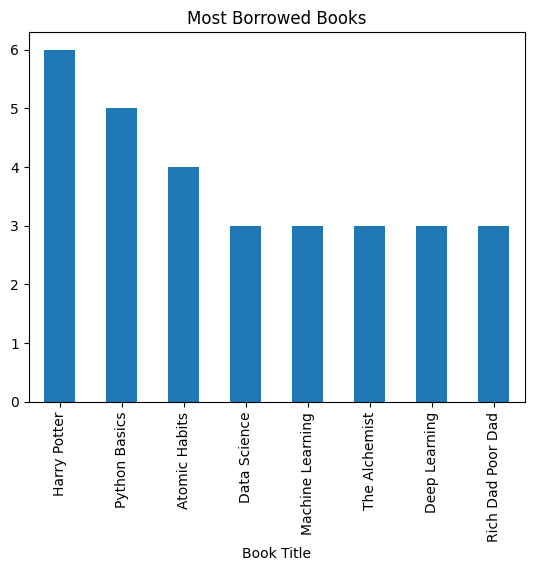

In [4]:
top_books = library.data["Book Title"].value_counts()

top_books.plot(kind="bar")

plt.title("Most Borrowed Books")

plt.show()

### Pie Chart

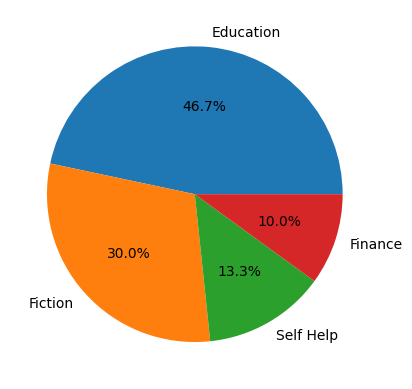

In [5]:
library.data["Genre"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.show()

### Line Chart

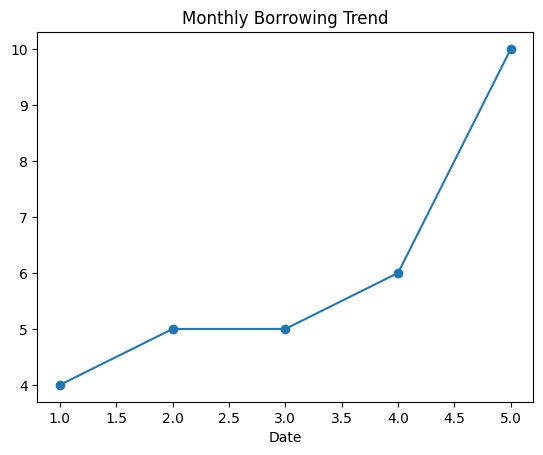

In [6]:
library.data["Date"] = pd.to_datetime(library.data["Date"])

monthly = library.data.groupby(library.data["Date"].dt.month).size()

monthly.plot(marker="o")

plt.title("Monthly Borrowing Trend")

plt.show()

### HeatMap

In [7]:
library.data["Date"] = pd.to_datetime(library.data["Date"])

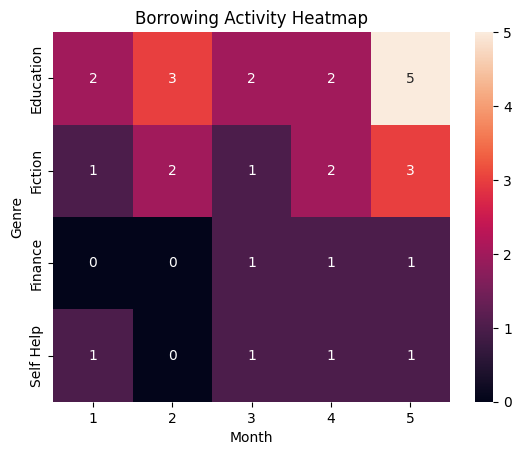

In [16]:
library.data["Month"] = (library.data["Date"].dt.month)

heat_data = pd.crosstab(library.data["Genre"], library.data["Month"])

sns.heatmap(heat_data,annot=True)

plt.title("Borrowing Activity Heatmap")
plt.show()